**Load Packages**

In [1]:
import pandas as pd
import numpy as np
import torch
import pymanopt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os
if not os.path.exists('figs'): os.makedirs('figs')
if not os.path.exists('data'): os.makedirs('data')

**Data Preprocessing**

In [2]:
df = pd.read_csv('data/bike+sharing+dataset/hour.csv')
df_X = df[['hr', 'temp', 'atemp', 'hum', 'windspeed', 'workingday']]
df_y = np.log(df['cnt']+1)   # outcome = count => log transformation

# source = Spring
id_s = df['season'] == 2
x_s = df_X[id_s].to_numpy()
y_s = df_y[id_s].to_numpy()

# target = Fall
id_t = df['season'] == 4
x_t = df_X[id_t].to_numpy()
y_t = df_y[id_t].to_numpy()

# sample size and dimension
n = len(y_s)
m = len(y_t)
d = x_s.shape[1]    # d = 6

**Regression**

We run the usual OLS regression using the source data, check its risk on the target data, and compare to the risk of the target OLS regression.

In [3]:
# transformation based on source data
x_s_avg = np.mean(x_s, axis=0)
x_s_std = np.std(x_s, axis=0)
x_t_avg = np.mean(x_t, axis=0)
x_t_std = np.std(x_t, axis=0)
x_s_scaled = (x_s - x_s_avg) / x_s_std
x_t_scaled = (x_t - x_s_avg) / x_s_std

# source risk
def R_s(beta):
    return np.mean((y_s - x_s_scaled @ beta)**2)

# target risk
def R_t(beta):
    return np.mean((y_t - x_t_scaled @ beta)**2)

# source OLS
res_s = sm.OLS(y_s, x_s_scaled).fit()
beta_s = res_s.params 
print('Source OLS risk =', R_s(beta_s))

# target OLS (oracle)
res_t = sm.OLS(y_t, x_t_scaled).fit()
beta_t = res_t.params
print('Target OLS risk (oracle) =', R_t(beta_t))
print('Target risk of source OLS =', R_t(beta_s))

Source OLS risk = 23.061925098585895
Target OLS risk (oracle) = 13.019213106410465
Target risk of source OLS = 26.56260572487534


**Hyperparameter Selection Based on Section 5.2**

In [4]:
# pooling data
x_pool = np.vstack([x_s, x_t])

# centering
x_pool_scaled = (x_pool - np.mean(x_pool, axis=0)) / np.std(x_pool, axis=0)
pca = PCA()
pca.fit(x_pool_scaled)
print('Singular values =', pca.singular_values_)
print('Explained variance ratio (cumulative) =', np.cumsum(pca.explained_variance_ratio_))

# choose the dimension (cumulative explained variance ratio > 0.90)
k = 5

# covariance matrices
cov_s = x_s_scaled.T @ x_s_scaled / n
cov_t = x_t_scaled.T @ x_t_scaled / m
D = cov_t - cov_s
xy_s = x_s_scaled.T @ y_s / n

# to torch tensors
x_s_ = torch.from_numpy(x_s_scaled)
y_s_ = torch.from_numpy(y_s)
cov_s_ = torch.from_numpy(cov_s)
D_ = torch.from_numpy(D)
xy_s_ = torch.from_numpy(xy_s)

# optimization
manifold = pymanopt.manifolds.stiefel.Stiefel(d, k) # Stiefel manifold
@pymanopt.function.pytorch(manifold)
def cost(V):
    return torch.norm(V.T @ D_ @ V)**2

problem = pymanopt.Problem(manifold, cost)
optimizer = pymanopt.optimizers.steepest_descent.SteepestDescent(verbosity=1, max_iterations=3000)
result = optimizer.run(problem, initial_point=np.eye(d,k)) # initialization

# obtained subspace
V_stable = result.point    # numpy array

# ups (ridge parameter) scale
print('(upsilon scale) 0.1 * Source risk / squared norm ratio =', 0.1*R_s(beta_s) / np.linalg.norm(beta_s)**2)

# eta (discrepancy parameter) scale
print('(eta scale) 2 * Source risk / discrepancy ratio =', 2*R_s(beta_s) / np.linalg.norm(V_stable.T @ D @ V_stable)**2)

Singular values = [136.48543318 107.15668951  93.45467818  85.25582812  75.15655335
   9.18312639]
Explained variance ratio (cumulative) = [0.35930011 0.5807744  0.74923054 0.88942566 0.99837346 1.        ]
Optimizing...
Terminated - min grad norm reached after 36 iterations, 0.04 seconds.

(upsilon scale) 0.1 * Source risk / squared norm ratio = 2.9310550973202507
(eta scale) 2 * Source risk / discrepancy ratio = 524.9962573251137


**Proposed Method**

Implement the proposed method (Algorithm 1).

In [5]:
# initialization = identity or stable subspace
V_init = np.eye(d,k)
#V_init = V_stable

# parameters
eta_range = np.array([0.01, 0.1, 5, 500, 20000, 1e6, 1e8, 1e10, 1e12])
ups_range = np.array([0, 0.1, 1, 3, 50])

# store results
Vs = np.zeros((len(ups_range), len(eta_range), d, k))
betas = np.zeros((len(ups_range), len(eta_range), d))
target_risks = np.zeros((len(ups_range), len(eta_range)))  # oracle target risk
source_risks = np.zeros((len(ups_range), len(eta_range)))
costs = np.zeros((len(ups_range), len(eta_range)))
discrepancies = np.zeros((len(ups_range), len(eta_range)))
grad_norms = np.zeros((len(ups_range), len(eta_range)))

# optimization
manifold = pymanopt.manifolds.stiefel.Stiefel(d, k) # Stiefel manifold
for i_ups, ups in enumerate(ups_range):
    for i_eta, eta in enumerate(eta_range):
        print(f'ups: {ups}, eta: {eta}')
        @pymanopt.function.pytorch(manifold)
        def cost(V):
            alpha_V = torch.linalg.pinv(V.T @ cov_s_ @ V + ups*torch.eye(k)) @ V.T @ xy_s_
            beta_V = V @ alpha_V
            risk_source = torch.mean((y_s_ - x_s_@beta_V)**2) + ups*torch.norm(alpha_V)**2
            discrepancy = torch.norm(V.T @ D_ @ V)**2

            return 0.5*risk_source + 0.25*eta*discrepancy

        problem = pymanopt.Problem(manifold, cost)
        optimizer = pymanopt.optimizers.steepest_descent.SteepestDescent(verbosity=1, max_iterations=3000)
        result = optimizer.run(problem, initial_point=V_init) # initialization
        
        # obtained beta
        V = result.point    # numpy array
        alpha_ridge = np.linalg.pinv(V.T @ cov_s @ V + ups*np.eye(k)) @ V.T @ xy_s
        beta_ridge = V @ alpha_ridge

        # store results
        Vs[i_ups,i_eta,:,:] = V
        betas[i_ups,i_eta,:] = beta_ridge
        target_risks[i_ups,i_eta] = R_t(beta_ridge)
        source_risks[i_ups,i_eta] = R_s(beta_ridge)
        costs[i_ups,i_eta] = problem.cost(V)
        discrepancies[i_ups,i_eta] = np.linalg.norm(V.T @ D @ V)**2
        grad_norms[i_ups,i_eta] = np.linalg.norm(problem.riemannian_gradient(V))

ups: 0.0, eta: 0.01
Optimizing...
Terminated - min grad norm reached after 1962 iterations, 0.77 seconds.

ups: 0.0, eta: 0.1
Optimizing...
Terminated - min grad norm reached after 238 iterations, 0.09 seconds.

ups: 0.0, eta: 5.0
Optimizing...
Terminated - min grad norm reached after 34 iterations, 0.01 seconds.

ups: 0.0, eta: 500.0
Optimizing...
Terminated - min grad norm reached after 49 iterations, 0.03 seconds.

ups: 0.0, eta: 20000.0
Optimizing...
Terminated - min step_size reached after 44 iterations, 0.02 seconds.

ups: 0.0, eta: 1000000.0
Optimizing...
Terminated - min step_size reached after 42 iterations, 0.02 seconds.

ups: 0.0, eta: 100000000.0
Optimizing...
Terminated - min step_size reached after 49 iterations, 0.02 seconds.

ups: 0.0, eta: 10000000000.0
Optimizing...
Terminated - min step_size reached after 45 iterations, 0.02 seconds.

ups: 0.0, eta: 1000000000000.0
Optimizing...
Terminated - min step_size reached after 46 iterations, 0.02 seconds.

ups: 0.1, eta: 0.0

**Plots**

Reproduce the plots in Figure 5 of the paper.

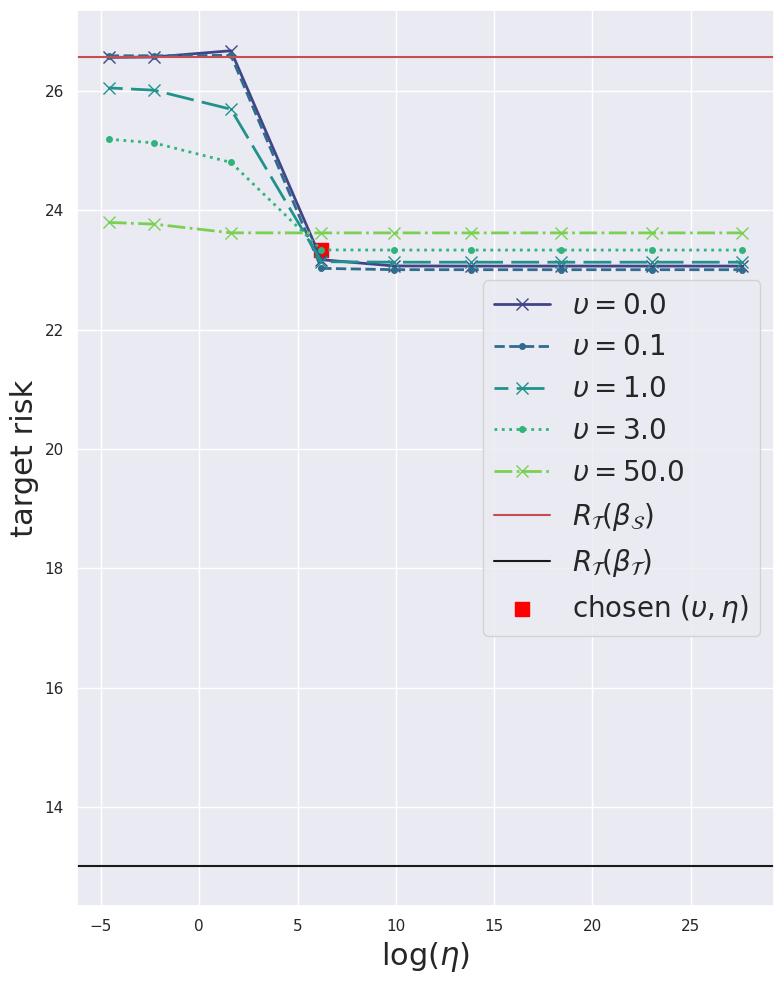

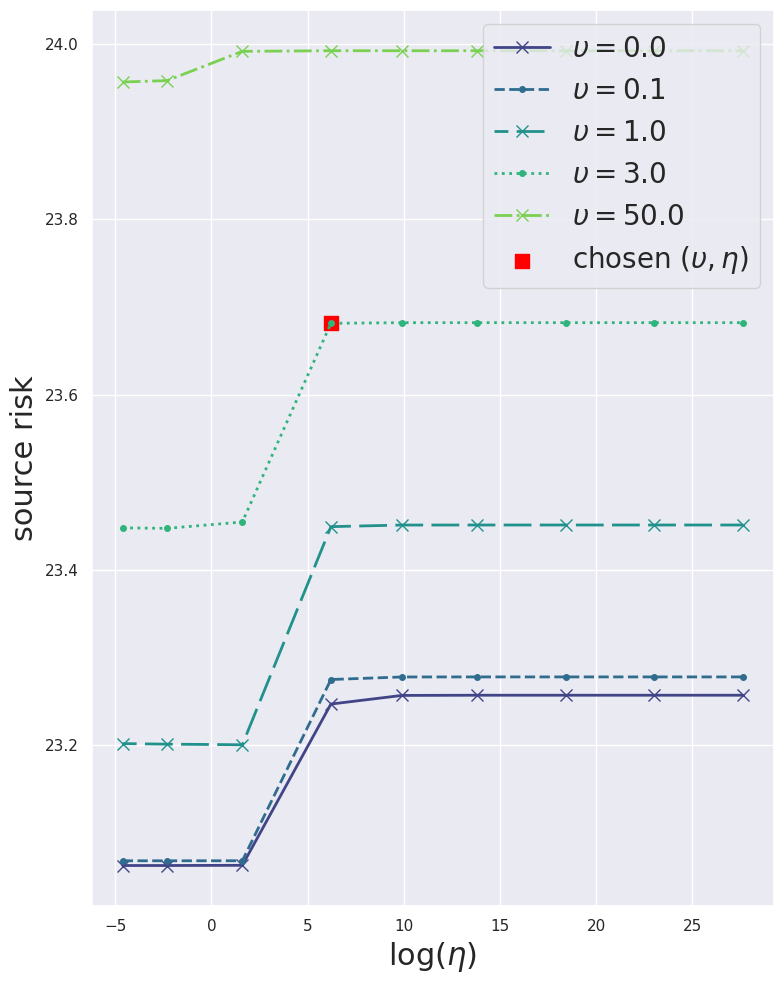

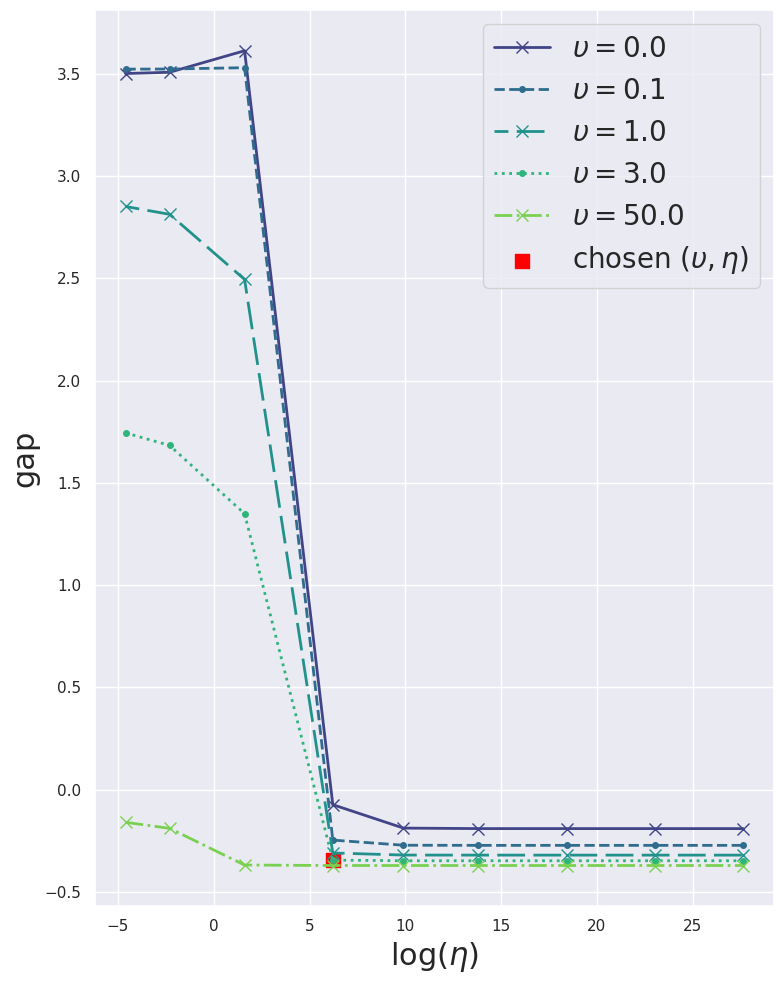

In [89]:
sns.set_theme()

linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]


linestyle_list = ['solid', 'dashed', (5, (10, 3)), 'dotted', 'dashdot']
marker_list = ['x', '.', 'x', '.', 'x']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ups_range)))

eta_id_chosen = 3
ups_id_chosen = 3
gap = target_risks - source_risks

# target risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), target_risks[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.axhline(R_t(beta_s), color='r', label=r'$R_\mathcal{T}(\beta_{\mathcal{S}})$')
plt.axhline(R_t(beta_t), color='k', label=r'$R_\mathcal{T}(\beta_{\mathcal{T}})$')
plt.scatter(np.log(eta_range[eta_id_chosen]), target_risks[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('target risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/bike_sharing_target_risk.pdf')
plt.show()

# source risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), source_risks[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.scatter(np.log(eta_range[eta_id_chosen]), source_risks[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('source risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/bike_sharing_source_risk.pdf')
plt.show()

# target risk - source risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), gap[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.scatter(np.log(eta_range[eta_id_chosen]), gap[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('gap', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/bike_sharing_target_source_difference.pdf')
plt.show()